Working with z of shape (1, 4, 16, 16, 16) = 16384 dimensions.


C:\Users\qingy\AppData\Local\Temp\ipykernel_37092\1174837297.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CKPT_PATH, map_location="cpu")


🚀 正在批量生成 10 组三视图对比图...
✅ 批量三视图对比已保存为 batch_3view_comparison.png


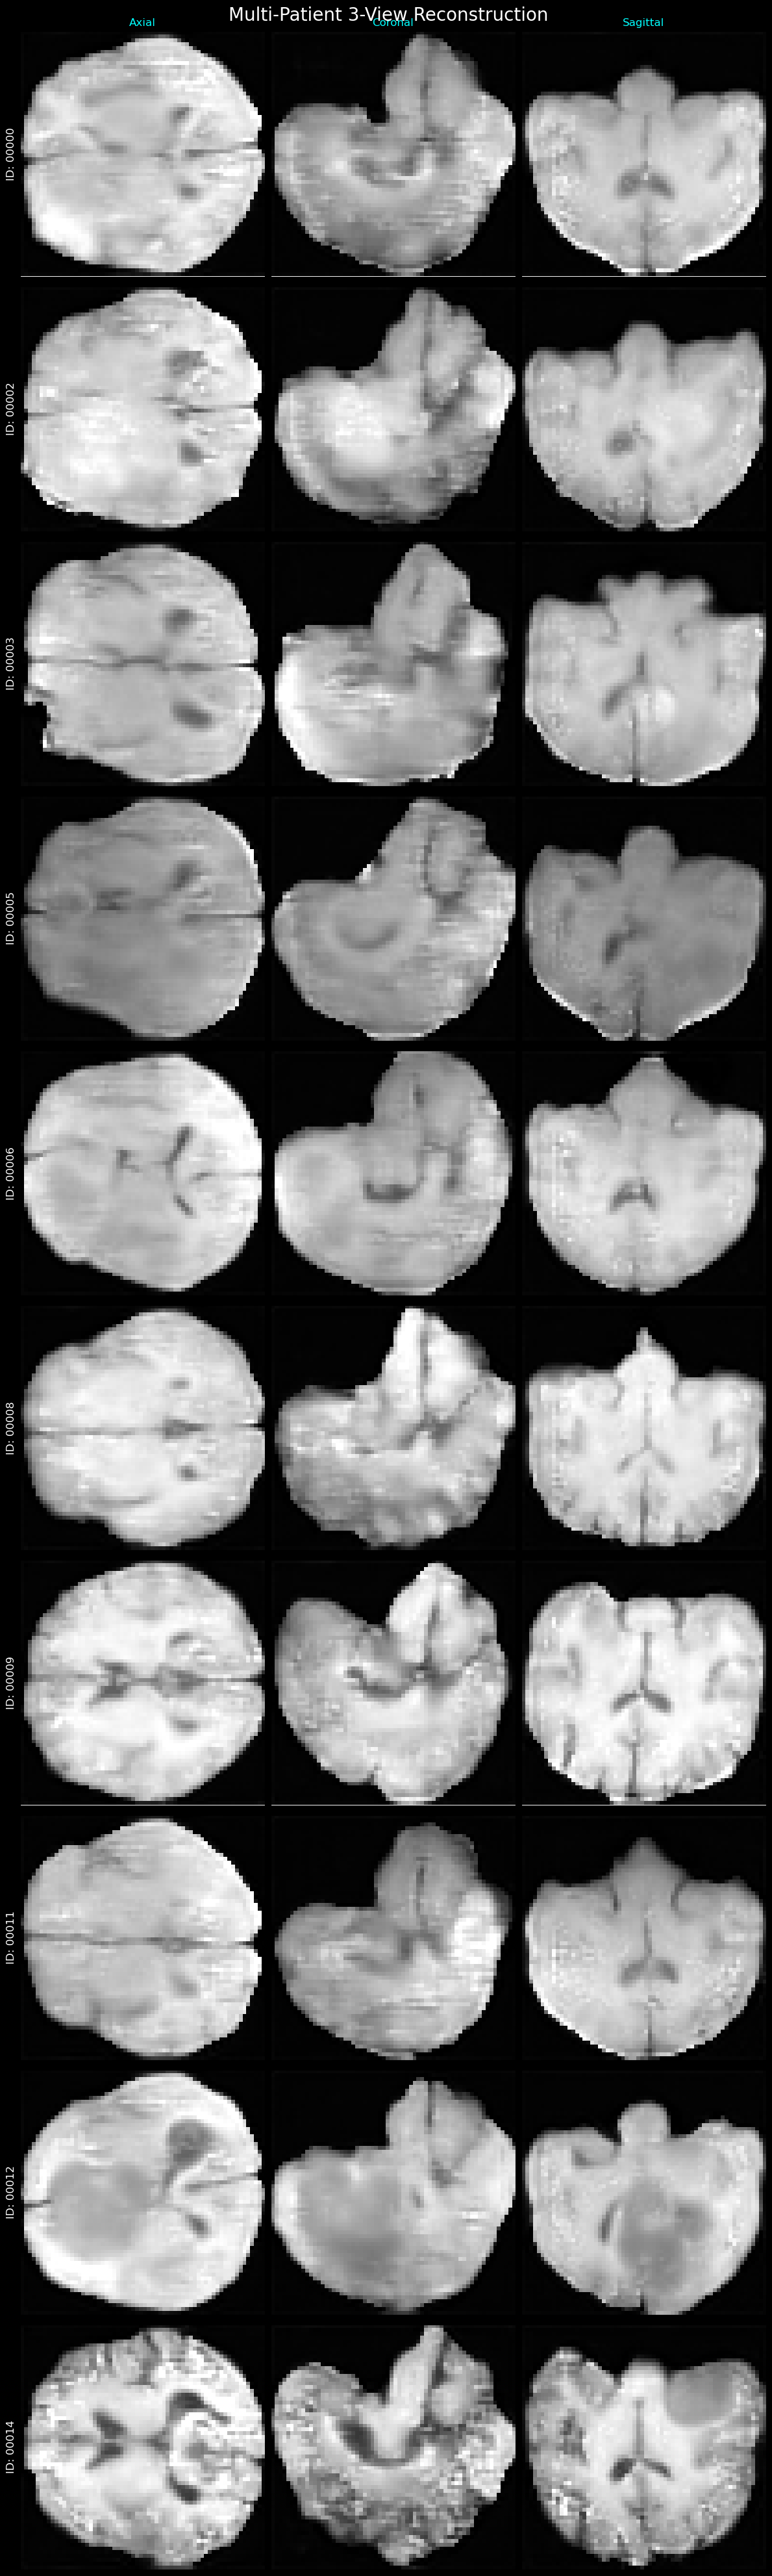

In [1]:
# 检查生成的 cache 文件，批量生成三视图对比图

import os
import torch
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from models import mar, vae
from models.vae import AutoencoderKL

# ---------------- 配置区域 ----------------
# 1. 你的权重路径
CKPT_PATH = r"vqgan\stage1.ckpt" 

# 3. 你的配置 (保持不变)
DDCONFIG = {
    "double_z": False, 
    "z_channels": 4, 
    "resolution": 64, 
    "in_channels": 1, 
    "out_ch": 1, 
    "ch": 64, 
    "num_groups": 32, 
    "ch_mult": [1, 1, 2], 
    "num_res_blocks": 1, 
    "attn_resolutions": [], 
    "dropout": 0.0
}

# ================= 配置 (手动指定 10 个 ID) =================
FILES_TO_CHECK = [
    "BraTS2021_00000_t1.npz",
    "BraTS2021_00002_t1.npz",
    "BraTS2021_00003_t1.npz",
    "BraTS2021_00005_t1.npz",
    "BraTS2021_00006_t1.npz",
    "BraTS2021_00008_t1.npz",
    "BraTS2021_00009_t1.npz",
    "BraTS2021_00011_t1.npz",
    "BraTS2021_00012_t1.npz",
    "BraTS2021_00014_t1.npz",
]
BASE_CACHE_PATH = r"output_cache/class0"
# ==========================================================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. 模型初始化 (只做一次)
    model = AutoencoderKL(DDCONFIG, 8192, 4)
    checkpoint = torch.load(CKPT_PATH, map_location="cpu")
    sd = checkpoint["state_dict"] if "state_dict" in checkpoint else checkpoint.get("model", checkpoint)
    model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    # 2. 创建画布：10 行，3 列
    num_files = len(FILES_TO_CHECK)
    fig, axes = plt.subplots(num_files, 3, figsize=(12, 4 * num_files))
    fig.patch.set_facecolor('black')

    print(f"🚀 正在批量生成 {num_files} 组三视图对比图...")

    for row_idx, file_name in enumerate(FILES_TO_CHECK):
        full_path = os.path.join(BASE_CACHE_PATH, file_name)
        
        if not os.path.exists(full_path):
            print(f"⚠️ 跳过：找不到 {file_name}")
            continue

        # 加载数据并解码
        data = np.load(full_path)
        z = data['moments'] 
        z_tensor = torch.from_numpy(z).unsqueeze(0).to(device).float()
        
        with torch.no_grad():
            quant = model.post_quant_conv(z_tensor)
            recon = model.decoder(quant)

        # 处理图像
        recon_np = recon.cpu().numpy()[0, 0] # [D, H, W]
        recon_img = np.clip(recon_np, -1, 1)
        recon_img = (recon_img + 1) / 2.0
        
        d_m, h_m, w_m = [s // 2 for s in recon_img.shape]
        patient_id = file_name.split('_')[1]

        # 绘图逻辑
        # Axial
        axes[row_idx, 0].imshow(recon_img[d_m, :, :], cmap='gray')
        axes[row_idx, 0].set_ylabel(f"ID: {patient_id}", color='white', fontsize=12)
        if row_idx == 0: axes[row_idx, 0].set_title("Axial", color='cyan')
        axes[row_idx, 0].set_xticks([]); axes[row_idx, 0].set_yticks([])

        # Coronal
        axes[row_idx, 1].imshow(recon_img[:, h_m, :], cmap='gray')
        if row_idx == 0: axes[row_idx, 1].set_title("Coronal", color='cyan')
        axes[row_idx, 1].set_xticks([]); axes[row_idx, 1].set_yticks([])

        # Sagittal
        axes[row_idx, 2].imshow(recon_img[:, :, w_m], cmap='gray')
        if row_idx == 0: axes[row_idx, 2].set_title("Sagittal", color='cyan')
        axes[row_idx, 2].set_xticks([]); axes[row_idx, 2].set_yticks([])

    plt.suptitle("Multi-Patient 3-View Reconstruction", color='white', fontsize=20, y=0.99)
    plt.tight_layout()
    plt.savefig("batch_3view_comparison.png", facecolor='black', bbox_inches='tight')
    print("✅ 批量三视图对比已保存为 batch_3view_comparison.png")

if __name__ == "__main__":
    main()